In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay
import numpy as np
import matplotlib.pyplot as plt

In [10]:
trainData = pd.read_csv('../../Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv')
trainData

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,No,No,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


In [11]:
testData = pd.read_csv('../../Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv')
testData

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,WI,114,415,No,Yes,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2,False
663,AL,106,408,No,Yes,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1,False
664,VT,60,415,No,No,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3,False
665,WV,159,415,No,No,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1,False


In [12]:
trainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [13]:
trainData['International plan'] = trainData['International plan'].replace({'No': 0, 'Yes': 1})
trainData['Voice mail plan'] = trainData['Voice mail plan'].replace({'No': 0, 'Yes': 1})
trainData['Churn'] = trainData['Churn'].replace({False: 0, True: 1})

trainData

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,0,0,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,0
2662,AZ,192,415,0,1,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,0
2663,WV,68,415,0,0,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,0
2664,RI,28,510,0,0,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,0


In [14]:
testData['International plan'] = testData['International plan'].replace({'No': 0, 'Yes': 1})
testData['Voice mail plan'] = testData['Voice mail plan'].replace({'No': 0, 'Yes': 1})
testData['Churn'] = testData['Churn'].replace({False: 0, True: 1})

testData

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,0,0,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,0
1,IN,65,415,0,0,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,1
2,NY,161,415,0,0,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,1
3,SC,111,415,0,0,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,0
4,HI,49,510,0,0,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,WI,114,415,0,1,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2,0
663,AL,106,408,0,1,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1,0
664,VT,60,415,0,0,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3,0
665,WV,159,415,0,0,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1,0


In [17]:
numericFeatures = ['Account length', 'Number vmail messages', 'Total day minutes',
                    'Total day calls', 'Total day charge', 'Total eve minutes',
                    'Total eve calls', 'Total eve charge', 'Total night minutes',
                    'Total night calls', 'Total night charge', 'Total intl minutes',
                    'Total intl calls', 'Total intl charge', 'Customer service calls']

categoricalFeatures = ['State', 'Area code']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numericFeatures),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricalFeatures)
    ],
    remainder='drop',
)

In [19]:
pipeLR = Pipeline([("perp", preprocessor),
                   ("clf", LogisticRegression(max_iter=100))])

pipeDT = Pipeline([("perp", preprocessor),
                   ("clf", DecisionTreeClassifier(random_state=42))])

pipeRF = Pipeline([("perp", preprocessor),
                   ("clf", RandomForestClassifier(random_state=42))])

param_grid_lr = {
    "clf__penalty": ["l2"],
    "clf__C": [0.1, 1.0, 10.0],
    "clf__solver": ["lbfgs"],  
}

param_grid_dt = {
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 10, 20],
    "clf__min_samples_leaf": [1, 5, 10],
}

param_grid_rf = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 10],
    "clf__min_samples_leaf": [1, 4],
}

models = [
    ("LogisticRegression", pipeLR, param_grid_lr),
    ("DecisionTree",      pipeDT, param_grid_dt),
    ("RandomForest",      pipeRF, param_grid_rf),
]

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

In [21]:
X_train = trainData.drop(['Churn'], axis=1)
X_test = testData.drop(['Churn'], axis=1)
y_train = trainData['Churn']
y_test = testData['Churn']

In [22]:
results = []

for name, pipe, grid in models:
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="f1",            
        cv=5,
        n_jobs=-1,
        verbose=0,
        return_train_score=False
    )
    gs.fit(X_train, y_train)

    best = gs.best_estimator_
    y_pred = best.predict(X_test)

    # Collect scores on test set
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results.append({
        "model": name,
        "best_params": gs.best_params_,
        "cv_best_f1": gs.best_score_,
        "test_accuracy": acc,
        "test_precision": prec,
        "test_recall": rec,
        "test_f1": f1
    })

summary = pd.DataFrame(results).sort_values("test_f1", ascending=False)
print(summary)

c:\Users\Farida\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                model                                        best_params  \
1        DecisionTree  {'clf__max_depth': 5, 'clf__min_samples_leaf':...   
2        RandomForest  {'clf__max_depth': None, 'clf__min_samples_lea...   
0  LogisticRegression  {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__s...   

   cv_best_f1  test_accuracy  test_precision  test_recall   test_f1  
1    0.775422       0.940030        0.903995     0.837753  0.866509  
2    0.770479       0.925037        0.932439     0.750009  0.807723  
0    0.560050       0.863568        0.718348     0.591277  0.614850  



Best model: DecisionTree
Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 20}

Classification report (test):

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       572
           1       0.86      0.69      0.77        95

    accuracy                           0.94       667
   macro avg       0.90      0.84      0.87       667
weighted avg       0.94      0.94      0.94       667



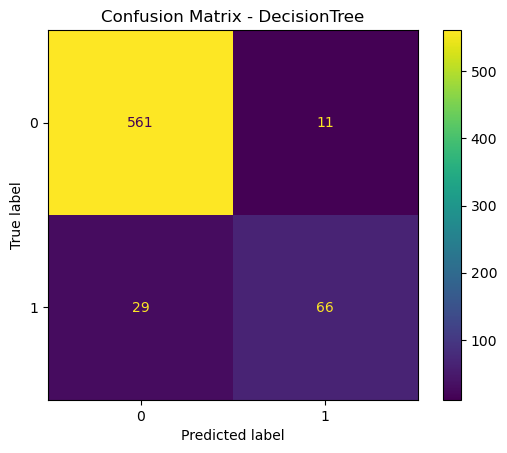

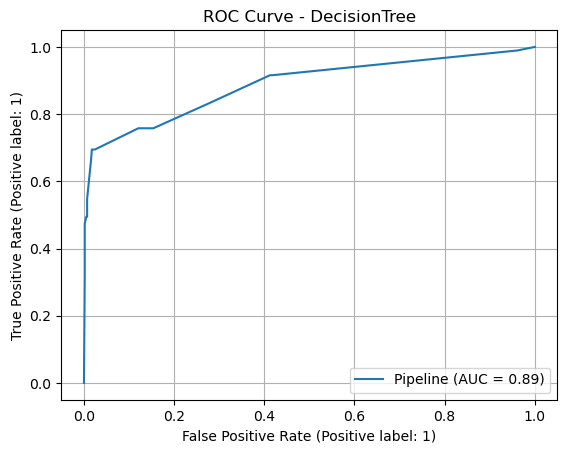

Test ROC AUC: 0.8865936694884063


In [25]:
best_row   = summary.iloc[0]
best_name  = best_row["model"]

chosen = next(m for m in models if m[0] == best_name)
chosen_pipe = GridSearchCV(
    estimator=chosen[1],
    param_grid=chosen[2],
    scoring=scoring,
    refit="f1",
    cv=5,
    n_jobs=-1,
)
chosen_pipe.fit(X_train, y_train)
best_model = chosen_pipe.best_estimator_

y_pred = best_model.predict(X_test)

print(f"\nBest model: {best_name}")
print("Best params:", chosen_pipe.best_params_)
print("\nClassification report (test):\n")
print(classification_report(y_test, y_pred, zero_division=0))

disp = ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"Confusion Matrix - {best_name}")
plt.grid(False)
plt.show()

try:
    if len(np.unique(y_test)) == 2:
        RocCurveDisplay.from_estimator(best_model, X_test, y_test)
        plt.title(f"ROC Curve - {best_name}")
        plt.grid(True)
        plt.show()
        # AUC score
        y_prob = best_model.predict_proba(X_test)[:, 1]
        print("Test ROC AUC:", roc_auc_score(y_test, y_prob))
except Exception as e:
    print("ROC/AUC not available:", e)